In [ ]:
import json
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.combine import SMOTETomek
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
def load_train_test(train_path, test_path, target_col='is_fraud'):
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_test  = test_df.drop(columns=[target_col])
    y_test  = test_df[target_col]

    return X_train, y_train, X_test, y_test


In [ ]:
def preprocess_data(X_train, X_test, categorical_cols):
  # Encoding categorical columns and Scaling numeric features
    numerical_cols = [c for c in X_train.columns if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),categorical_cols)
        ]
    )

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_test_processed, preprocessor


In [ ]:
def apply_smote_tomek(X_train, y_train, random_state=42):
    smt = SMOTETomek(random_state=random_state)
    X_resampled, y_resampled = smt.fit_resample(X_train, y_train)

    return X_resampled, y_resampled


In [ ]:
def train_base_models(X_resampled, y_resampled,random_state=42):
    models = {
        "logistic_regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=random_state
        ),
        "knn": KNeighborsClassifier(
            n_neighbors=15,
            weights="distance"
        ),
        "random_forest": RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=20,
            class_weight="balanced_subsample",
            random_state=random_state,
            n_jobs=-1
        ),
        "gaussian_nb": GaussianNB()
    }

    # Training all models on scaled and resampled data
    for model in models.values():
        model.fit(X_resampled, y_resampled)

    return models


In [ ]:
def max_probability_aggregation_recall(models, X_test_scaled):
  # Max probability aggregation function
    p_lr  = models["logistic_regression"].predict_proba(X_test_scaled)[:, 1]
    p_knn = models["knn"].predict_proba(X_test_scaled)[:, 1]
    p_rf  = models["random_forest"].predict_proba(X_test_scaled)[:, 1]
    p_gnb = models["gaussian_nb"].predict_proba(X_test_scaled)[:, 1]

    stacked = np.vstack([p_lr, p_knn, p_rf, p_gnb])
    return np.max(stacked, axis=0)


In [ ]:
def evaluate_and_save_results(y_test, y_prob, threshold=0.5, json_path="evaluation_results.json"):
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)

    fpr, tpr, roc_thr = roc_curve(y_test, y_prob)
    precision, recall, pr_thr = precision_recall_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        "classification_report": report,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "confusion_matrix": {
            "labels": ["non_fraud", "fraud"],
            "matrix": cm.tolist()
        },
        "roc_curve": {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": roc_thr.tolist()
        },
        "precision_recall_curve": {
            "precision": precision.tolist(),
            "recall": recall.tolist(),
            "thresholds": pr_thr.tolist()
        }
    }

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    return results


In [ ]:
# Loading the data
X_train, y_train, X_test, y_test = load_train_test(PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/train.csv", PROJECT_ROOT / "Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/test.csv")

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
target_col = 'is_fraud'

# Data Preprocessing
X_train_p, X_test_p, preprocessor = preprocess_data(
    X_train, X_test, categorical_cols
)
#  Applying SMOTE-Tomek
X_resampled, y_resampled = apply_smote_tomek(X_train_p, y_train, random_state=42)

# Training models with SMOTE-Tomek
models = train_base_models(X_resampled, y_resampled)

# Max Probability Aggregation (Recall-Oriented)
p_maxprob = max_probability_aggregation_recall(models, X_test_p)


In [ ]:
y_train.value_counts(), y_resampled.value_counts()


(is_fraud
 0    234466
 1      5290
 Name: count, dtype: int64,
 is_fraud
 0    234466
 1    234466
 Name: count, dtype: int64)

In [ ]:
# Model Evaluation
results = evaluate_and_save_results(
    y_test,
    p_maxprob,
    threshold=0.5,
    json_path="results/Baseline_model_with_max_probability_aggregation_results.json"
)

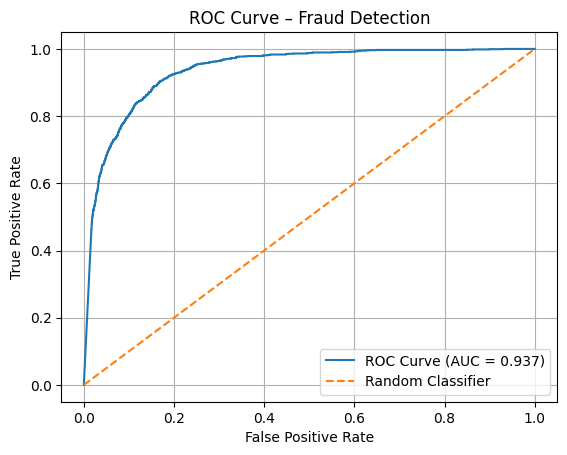

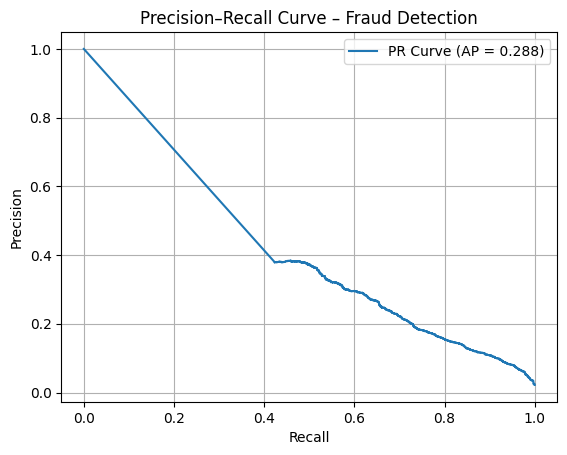

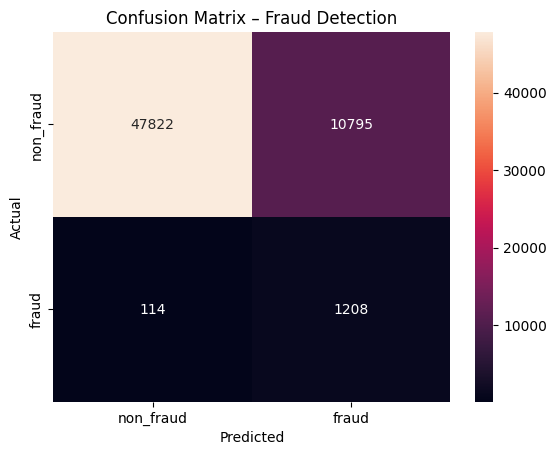

In [ ]:
# Evalution Results

# ROC Curve
fpr = results["roc_curve"]["fpr"]
tpr = results["roc_curve"]["tpr"]
roc_auc = results["roc_auc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

# PR Curve
precision = results["precision_recall_curve"]["precision"]
recall = results["precision_recall_curve"]["recall"]
avg_precision = results["average_precision"]

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array(results["confusion_matrix"]["matrix"])
labels = results["confusion_matrix"]["labels"]

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Fraud Detection")
plt.show()